In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Exercises

There are three exercises in this notebook:

1. Use the cross-validation method to test the linear regression with different $\alpha$ values, at least three.
2. Implement a SGD method that will train the Lasso regression for 10 epochs.
3. Extend the Fisher's classifier to work with two features. Use the class as the $y$.

## 1. Cross-validation linear regression

You need to change the variable ``alpha`` to be a list of alphas. Next do a loop and finally compare the results.

/tmp/ipykernel_50928/588990613.py:21: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.plot(lin_x ,lin_x * float(w_arr[i].T[1]) + float(w_arr[i].T[0]), label = f'w = {float(w_arr[i].T[0]):.2f}, {float(w_arr[i].T[1]):.2f}')


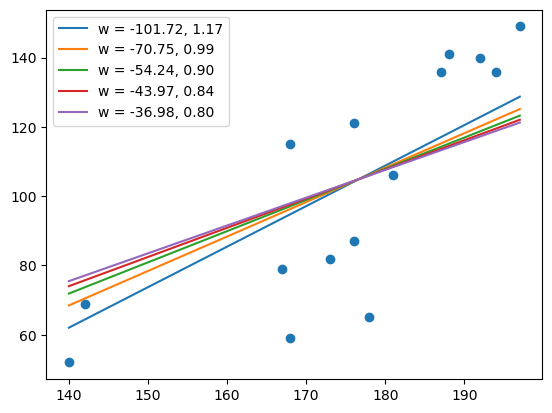

In [2]:
x = np.array([188, 181, 197, 168, 167, 187, 178, 194, 140, 176, 168, 192, 173, 142, 176]).reshape(-1, 1).reshape(15,1)
y = np.array([141, 106, 149, 59, 79, 136, 65, 136, 52, 87, 115, 140, 82, 69, 121]).reshape(-1, 1).reshape(15,1)

x = np.asmatrix(np.c_[np.ones((15,1)),x])

I = np.identity(2)
n = 5
alpha_arr = np.linspace(0.1,0.5,n)

w_arr = []
for alpha in alpha_arr:
    w = np.linalg.inv(x.T*x + alpha * I)*x.T*y
    w_arr.append(w.ravel())

x_list = [188, 181, 197, 168, 167, 187, 178, 194, 140, 176, 168, 192, 173, 142, 176]
y_list = [141, 106, 149, 59, 79, 136, 65, 136, 52, 87, 115, 140, 82, 69, 121]
lin_x = np.array([min(x_list), max(x_list)])

plt.scatter(x_list,y_list)
for i in range(n):
    plt.plot(lin_x ,lin_x * float(w_arr[i].T[1]) + float(w_arr[i].T[0]), label = f'w = {float(w_arr[i].T[0]):.2f}, {float(w_arr[i].T[1]):.2f}')
plt.legend()

## 2. Implement based on the Ridge regression example, the Lasso regression.

Please implement the SGD method and compare the results with the sklearn Lasso regression results. 

In [3]:
def sgd(x,y,r,iterations):
    w1 = 0
    w0 = 0
    
    for _ in range(iterations):
        y_hat = w1 * x + w0
        J_dw1 = np.sum(-2 * x * (y - y_hat))
        J_dw0 = np.sum(-2 * (y - y_hat))
        w1 = w1 - r * J_dw1
        w0 = w0 - r * J_dw0
        
    return w0, w1

In [4]:
def standarise(arr):
    mean = np.mean(arr)
    stdev = np.std(arr)
    return np.array([(x - mean)/stdev for x in arr])

In [5]:
x = np.array([188, 181, 197, 168, 167, 187, 178, 194, 140, 176, 168, 192, 173, 142, 176]).reshape(-1, 1).reshape(15,1)
y = np.array([141, 106, 149, 59, 79, 136, 65, 136, 52, 87, 115, 140, 82, 69, 121]).reshape(-1, 1).reshape(15,1)

x = np.asmatrix(np.c_[np.ones((15,1)),x])

I = np.identity(2)
alpha = 0.1 

w = np.linalg.inv(x.T*x + alpha * I)*x.T*y
w=w.ravel()

r = 0.06
iterations = 10000
x_list = np.array([188, 181, 197, 168, 167, 187, 178, 194, 140, 176, 168, 192, 173, 142, 176])
y_list = np.array([141, 106, 149, 59, 79, 136, 65, 136, 52, 87, 115, 140, 82, 69, 121])
stan_x_list = standarise(x_list)
w_sgd = sgd(stan_x_list,y_list,r,iterations)

In [6]:
from sklearn.linear_model import Lasso

x = np.array([188, 181, 197, 168, 167, 187, 178, 194, 140, 176, 168, 192, 173, 142, 176]).reshape(-1, 1).reshape(15,1)
y = np.array([141, 106, 149, 59, 79, 136, 65, 136, 52, 87, 115, 140, 82, 69, 121]).reshape(-1, 1).reshape(15,1)

alpha = 0.1

lasso_regression = Lasso(alpha=alpha)
lasso_regression.fit(X=x, 
                      y=y)
lasso_regression.coef_, lasso_regression.intercept_ 


(array([1.61776499]), array([-180.8579086]))

Text(0.5, 1.0, 'sklern')

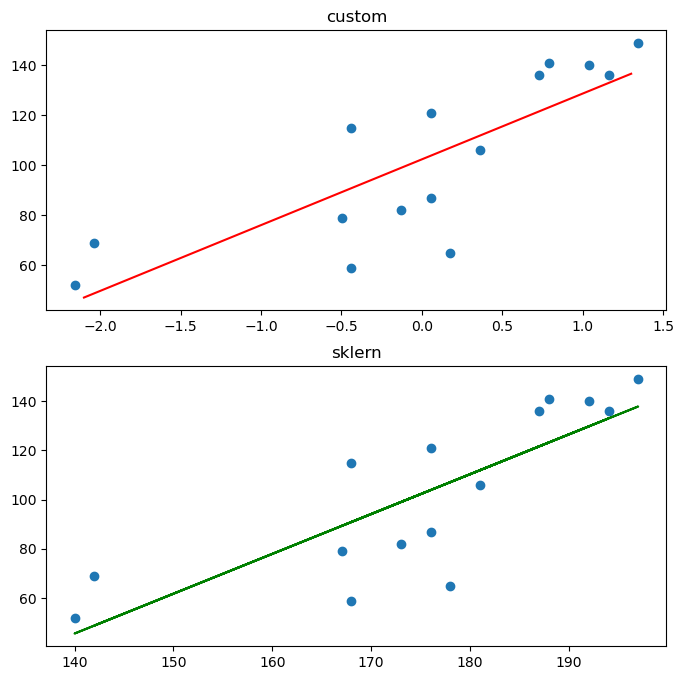

In [7]:
plt.figure(figsize=(8,8))
plt.subplot(2,1,1)
plt.scatter(standarise(x_list),y_list)
plt.plot(np.linspace(-2.1,1.3,10),np.linspace(-2.1,1.3,10)*w_sgd[1] + w_sgd[0], color='r')
plt.title('custom')
plt.subplot(2,1,2)
plt.scatter(x_list,y_list)
plt.plot(x_list,x_list*lasso_regression.coef_ + lasso_regression.intercept_, color='g')
plt.title('sklern')

## 3. Extend the Fisher's classifier

Please extend the targets of the ``iris_data`` variable and use it as the $y$.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn import preprocessing

iris_data, iris_labels = load_iris(return_X_y=True)
iris_data_norm = np.array(preprocessing.normalize(iris_data))
iris_data = load_iris()
iris_df = pd.DataFrame(iris_data_norm,columns=iris_data.feature_names)

x1 = iris_df['sepal width (cm)'].values
x2 = iris_df['sepal length (cm)'].values
y = iris_labels

X = np.column_stack((x1, x2))
binary_filter = y < 2
X_bin = X[binary_filter]
y_bin = y[binary_filter]
X_0 = X_bin[y_bin == 0]
X_1 = X_bin[y_bin == 1]

m_0 = np.mean(X_0, axis=0)
m_1 = np.mean(X_1, axis=0)
S_0 = np.dot((X_0 - m_0).T, (X_0 - m_0))
S_1 = np.dot((X_1 - m_1).T, (X_1 - m_1))
S_w = S_0 + S_1
S_w_inv = np.linalg.inv(S_w)
w_1 = np.dot(S_w_inv, (m_1 - m_0))
w_0 = 0.5 * (np.dot(w_1.T, m_1) + np.dot(w_1.T, m_0))

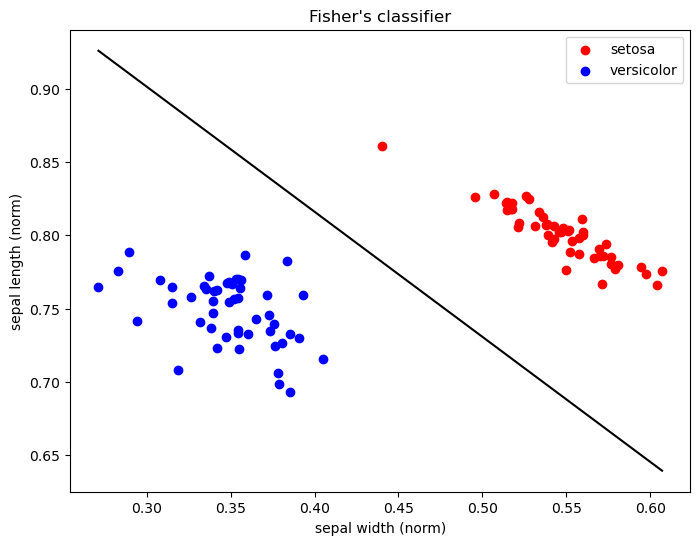

In [9]:
plt.figure(figsize=(8, 6))
plt.scatter(X_0[:, 0], X_0[:, 1], color='red', label=iris_data.target_names[0])
plt.scatter(X_1[:, 0], X_1[:, 1], color='blue', label=iris_data.target_names[1])

x_min, x_max = X_bin[:, 0].min(), X_bin[:, 0].max()
boundary_x1 = np.array([x_min, x_max])
boundary_x2 = (w_0 - w_1[0] * boundary_x1) / w_1[1]

plt.plot(boundary_x1, boundary_x2, color='black')

plt.xlabel('sepal width (norm)')
plt.ylabel('sepal length (norm)')
plt.title("Fisher's classifier")
plt.legend()